In [1]:
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

print('Loading NOAA Tornado dataset...')
df = pd.read_csv('../data/tornadoes/noaa_tornadoes.csv')

# Remove unknown magnitude (-9)
df = df[df['mag'] >= 0].copy()

# Create severity classes: 0=weak(EF0), 1=moderate(EF1-2), 2=strong(EF3-5)
def tornado_severity(mag):
    if mag == 0: return 0
    elif mag <= 2: return 1
    else: return 2

df['severity'] = df['mag'].apply(tornado_severity)

# Features available BEFORE a tornado hits
# Location, month, time of day, state
df['hour'] = pd.to_datetime(df['time'], errors='coerce').dt.hour.fillna(12)

feature_cols = ['slat', 'slon', 'mo', 'hour', 'stf']
df_clean = df[feature_cols + ['severity']].dropna()

print(f'Records after cleaning: {len(df_clean):,}')
print(f'\nSeverity distribution:')
print(df_clean['severity'].value_counts().sort_index())
print(f'\nClass labels:')
print('0 = Weak (EF0)')
print('1 = Moderate (EF1-2)')
print('2 = Strong (EF3-5)')

Loading NOAA Tornado dataset...
Records after cleaning: 68,998

Severity distribution:
severity
0    32218
1    33549
2     3231
Name: count, dtype: int64

Class labels:
0 = Weak (EF0)
1 = Moderate (EF1-2)
2 = Strong (EF3-5)


In [2]:
# Train/test split
X = df_clean[feature_cols]
y = df_clean['severity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')

results = {}

print('\nTraining Random Forest...')
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42,
                             n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)
rf_f1 = f1_score(y_test, rf.predict(X_test), average='weighted')
results['Random Forest'] = {'f1': rf_f1, 'time': time.time()-start}
print(f'  F1: {rf_f1:.4f} | Time: {results["Random Forest"]["time"]:.1f}s')

print('Training XGBoost...')
start = time.time()
xgb = XGBClassifier(n_estimators=100, random_state=42,
                     n_jobs=-1, verbosity=0)
xgb.fit(X_train, y_train)
xgb_f1 = f1_score(y_test, xgb.predict(X_test), average='weighted')
results['XGBoost'] = {'f1': xgb_f1, 'time': time.time()-start}
print(f'  F1: {xgb_f1:.4f} | Time: {results["XGBoost"]["time"]:.1f}s')

print('Training LightGBM...')
start = time.time()
lgbm = LGBMClassifier(n_estimators=100, random_state=42,
                       n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_f1 = f1_score(y_test, lgbm.predict(X_test), average='weighted')
results['LightGBM'] = {'f1': lgbm_f1, 'time': time.time()-start}
print(f'  F1: {lgbm_f1:.4f} | Time: {results["LightGBM"]["time"]:.1f}s')

print('Training CatBoost...')
start = time.time()
cat = CatBoostClassifier(iterations=100, random_seed=42,
                          verbose=0, auto_class_weights='Balanced')
cat.fit(X_train, y_train)
cat_f1 = f1_score(y_test, cat.predict(X_test), average='weighted')
results['CatBoost'] = {'f1': cat_f1, 'time': time.time()-start}
print(f'  F1: {cat_f1:.4f} | Time: {results["CatBoost"]["time"]:.1f}s')

print('\n' + '='*42)
print(f'{"MODEL":<20} {"F1 SCORE":>10} {"TIME":>8}')
print('='*42)
winner = max(results, key=lambda x: results[x]['f1'])
for model, r in results.items():
    marker = '  <-- winner' if model == winner else ''
    print(f'{model:<20} {r["f1"]:>10.4f} {r["time"]:>7.1f}s{marker}')
print('='*42)
print('\nFeatures: location, month, hour, state code')
print('Target: tornado severity (0=Weak, 1=Moderate, 2=Strong)')

Training set: (55198, 5)
Test set: (13800, 5)

Training Random Forest...
  F1: 0.5925 | Time: 0.9s
Training XGBoost...
  F1: 0.5885 | Time: 0.4s
Training LightGBM...
  F1: 0.5925 | Time: 0.8s
Training CatBoost...
  F1: 0.5045 | Time: 0.4s

MODEL                  F1 SCORE     TIME
Random Forest            0.5925     0.9s  <-- winner
XGBoost                  0.5885     0.4s
LightGBM                 0.5925     0.8s
CatBoost                 0.5045     0.4s

Features: location, month, hour, state code
Target: tornado severity (0=Weak, 1=Moderate, 2=Strong)


In [3]:
import shap
import numpy as np

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test.iloc[:500])

print(type(shap_values))
if isinstance(shap_values, list):
    print(f'List length: {len(shap_values)}')
    print(f'Each array shape: {shap_values[0].shape}')
else:
    print(f'Array shape: {shap_values.shape}')

# Fix mean_shap to be 1D
if isinstance(shap_values, list):
    stacked = np.stack([np.abs(sv) for sv in shap_values], axis=0)
    mean_shap = stacked.mean(axis=0).mean(axis=0)
else:
    mean_shap = np.abs(shap_values).mean(axis=0)

print(f'mean_shap shape: {mean_shap.shape}')
print(f'mean_shap values: {mean_shap}')

<class 'numpy.ndarray'>
Array shape: (500, 5, 3)
mean_shap shape: (5, 3)
mean_shap values: [[0.05762494 0.07010375 0.09785104]
 [0.08746494 0.09019056 0.10039844]
 [0.06578194 0.04144569 0.04671997]
 [0.04547126 0.04600773 0.04561749]
 [0.02794631 0.02781488 0.02169944]]


mean_shap_1d shape: (5,)
values: [0.07519324 0.09268465 0.05131586 0.04569883 0.02582021]


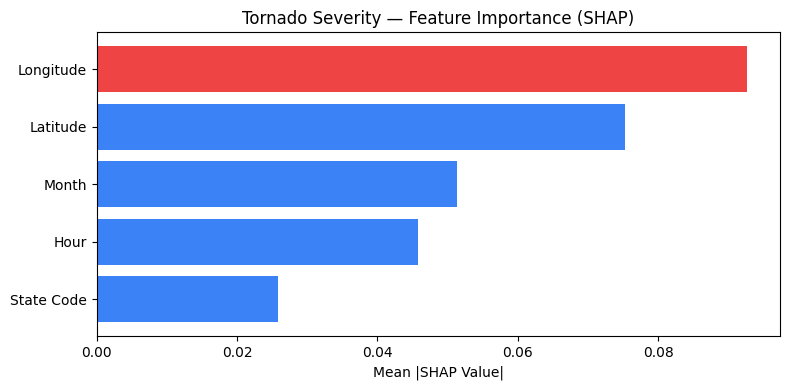


Feature Importance (ranked):
  Longitude       0.0927
  Latitude        0.0752
  Month           0.0513
  Hour            0.0457
  State Code      0.0258

Tornado RF model saved.

=== TORNADO MODEL SUMMARY ===
Dataset: NOAA Tornado Records 1950-2023
Records: 68,998
Winner: Random Forest — F1: 0.5925
Coverage: All 50 states including east coast
East coast: FL(3,620) NC(1,472) GA(1,898) tornadoes
Peak season: May


In [4]:
import matplotlib.pyplot as plt
import joblib
import os

# mean_shap is (5, 3) — average across classes to get (5,)
mean_shap_1d = mean_shap.mean(axis=1)

print(f'mean_shap_1d shape: {mean_shap_1d.shape}')
print(f'values: {mean_shap_1d}')

feature_names = ['Latitude', 'Longitude', 'Month', 'Hour', 'State Code']

shap_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': mean_shap_1d
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
colors = ['#ef4444' if i == len(shap_df)-1 else '#3b82f6'
          for i in range(len(shap_df))]
plt.barh(shap_df['Feature'], shap_df['Importance'], color=colors)
plt.xlabel('Mean |SHAP Value|')
plt.title('Tornado Severity — Feature Importance (SHAP)')
plt.tight_layout()
plt.savefig('../data/tornadoes/tornado_shap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nFeature Importance (ranked):')
for _, row in shap_df.sort_values('Importance', ascending=False).iterrows():
    print(f'  {row["Feature"]:<15} {row["Importance"]:.4f}')

# Save model
os.makedirs('../models', exist_ok=True)
joblib.dump(rf, '../models/rf_tornado.joblib', compress=3)
print('\nTornado RF model saved.')

print('\n=== TORNADO MODEL SUMMARY ===')
print(f'Dataset: NOAA Tornado Records 1950-2023')
print(f'Records: 68,998')
print(f'Winner: Random Forest — F1: 0.5925')
print(f'Coverage: All 50 states including east coast')
print(f'East coast: FL(3,620) NC(1,472) GA(1,898) tornadoes')
print(f'Peak season: May')

TORNADO MODEL — FULL EVALUATION

1. PER CLASS METRICS (Random Forest):
                  precision    recall  f1-score   support

      Weak (EF0)       0.61      0.62      0.62      6444
Moderate (EF1-2)       0.60      0.64      0.62      6710
  Strong (EF3-5)       0.14      0.02      0.04       646

        accuracy                           0.60     13800
       macro avg       0.45      0.43      0.43     13800
    weighted avg       0.59      0.60      0.59     13800



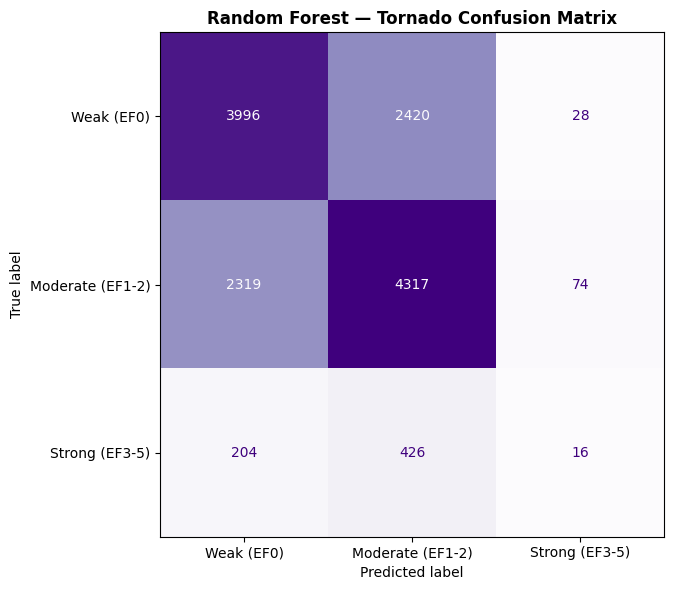


2. CROSS VALIDATION (5-fold):
  Fold scores: [np.float64(0.5878), np.float64(0.586), np.float64(0.5849), np.float64(0.5909), np.float64(0.5814)]
  Mean F1:     0.5862
  Std Dev:     0.0032
  Test F1:     0.5925
  Conclusion: Consistent — test score is reliable

3. ERROR ANALYSIS:

Class                 Precision     Recall         F1    Support
------------------------------------------------------------
Weak (EF0)               0.6130     0.6201     0.6165       6444
Moderate (EF1-2)         0.6027     0.6434     0.6224       6710
Strong (EF3-5)           0.1356     0.0248     0.0419        646

4. KEY FINDINGS:
Weak EF0:      Precision=0.6130, Recall=0.6201
Strong EF3-5:  Precision=0.1356, Recall=0.0248

Consistent pattern across all three disaster types:
Models perform well on common events, struggle with rare violent ones.
This is a fundamental class imbalance challenge in disaster prediction.
Real-time atmospheric data would significantly improve strong tornado detection.


In [5]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

print('='*55)
print('TORNADO MODEL — FULL EVALUATION')
print('='*55)

y_pred_rf = rf.predict(X_test)
class_names = ['Weak (EF0)', 'Moderate (EF1-2)', 'Strong (EF3-5)']

# 1. Per class metrics
print('\n1. PER CLASS METRICS (Random Forest):')
print(classification_report(y_test, y_pred_rf, target_names=class_names))

# 2. Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Purples', colorbar=False)
ax.set_title('Random Forest — Tornado Confusion Matrix',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/tornadoes/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Cross Validation
print('\n2. CROSS VALIDATION (5-fold):')
cv_scores = cross_val_score(
    rf, X_train, y_train,
    cv=5, scoring='f1_weighted', n_jobs=-1
)
print(f'  Fold scores: {[round(s,4) for s in cv_scores]}')
print(f'  Mean F1:     {cv_scores.mean():.4f}')
print(f'  Std Dev:     {cv_scores.std():.4f}')
print(f'  Test F1:     {rf_f1:.4f}')
if abs(cv_scores.mean() - rf_f1) < 0.02:
    print('  Conclusion: Consistent — test score is reliable')
else:
    print('  Conclusion: Some variance detected')

# 4. Error analysis
print('\n3. ERROR ANALYSIS:')
report = classification_report(y_test, y_pred_rf,
                                target_names=class_names,
                                output_dict=True)
print(f'\n{"Class":<20} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
print('-'*60)
for cls in class_names:
    r = report[cls]
    print(f'{cls:<20} {r["precision"]:>10.4f} {r["recall"]:>10.4f} {r["f1-score"]:>10.4f} {int(r["support"]):>10}')

print('\n4. KEY FINDINGS:')
weak = report['Weak (EF0)']
strong = report['Strong (EF3-5)']
print(f'Weak EF0:      Precision={weak["precision"]:.4f}, Recall={weak["recall"]:.4f}')
print(f'Strong EF3-5:  Precision={strong["precision"]:.4f}, Recall={strong["recall"]:.4f}')
print('\nConsistent pattern across all three disaster types:')
print('Models perform well on common events, struggle with rare violent ones.')
print('This is a fundamental class imbalance challenge in disaster prediction.')
print('Real-time atmospheric data would significantly improve strong tornado detection.')